# Text Summarization: TF-IDF Extractive Summarization from Scratch vs. Scikit-Learn

This notebook provides a hands-on exploration of **extractive text summarization using TF-IDF sentence scoring** — from a full NumPy from-scratch implementation to production-ready sklearn pipelines.

We load the **News Summary dataset** (human-written news article summaries), preprocess the text, implement a **TF-IDF sentence scorer using only NumPy**, compare with sklearn's `TfidfVectorizer`, and evaluate both using **ROUGE scores** (ROUGE-1, ROUGE-2, ROUGE-L).

## Prerequisites
- Term Frequency–Inverse Document Frequency (TF-IDF) fundamentals
- Text tokenization and preprocessing
- Basic ROUGE metric understanding
- sklearn `TfidfVectorizer` familiarity

## Dataset
[News Summary Dataset](https://www.kaggle.com/datasets/sunnysai12345/news-summary)

**Credits:** This dataset contains 8,500+ news articles with human-written summaries collected from various Indian news sources.

In [1]:
import numpy as np              # Numerical operations and array computations
import pandas as pd             # Data loading, manipulation, and analysis
import matplotlib.pyplot as plt # Plotting and visualizations
import seaborn as sns           # Enhanced statistical visualizations
import re                       # Regular expressions for text cleaning and tokenization
import math                     # Math functions (log) for TF-IDF computation
from collections import Counter # Counting word and n-gram frequencies
import warnings                 # Suppress deprecation and irrelevant warnings
import time                     # Benchmarking execution time
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF vectorization (used in Part 3)
from sklearn.model_selection import train_test_split         # Stratified train/test splitting

np.random.seed(42)  # Reproducibility across all random operations

## Part 1: Theory Recap — TF-IDF for Extractive Summarization

- **TF (Term Frequency):** Measures how often a word appears in a sentence. TF(t, s) = count of word t in sentence s / total words in sentence s. Normalizes for sentence length so longer sentences don't dominate.
- **IDF (Inverse Document Frequency):** Measures how rare a word is across all sentences. IDF(t) = log(N / df(t)) where N = total sentences and df(t) = number of sentences containing t. Words appearing in many sentences (e.g., 'the', 'is') get low IDF; rare topical words get high IDF.
- **TF-IDF = TF × IDF:** Each word gets a weight that balances local importance (TF) with global discriminability (IDF). The product up-weights words that are frequent within a sentence but rare across sentences — these are the topical keywords.
- **Sentence scoring:** Score(sentence) = Σ TF-IDF(word) over all words in the sentence. Sentences with higher cumulative TF-IDF contain more informative, discriminative words and are selected for the summary.
- **ROUGE metrics:** ROUGE-N measures n-gram recall between candidate and reference summary (how much of the reference is covered). ROUGE-L uses longest common subsequence to capture fluency and word-order similarity. All ROUGE scores are recall-focused.

### Loading the News Summary Dataset

We load the News Summary dataset from a publicly accessible source. The dataset contains over 4,000 news articles with corresponding human-written reference summaries.

**Column mapping:**
- `ctext` → **Full article text** (our input)
- `text`  → **Reference summary** (our target)

Our task: extract the most informative sentences from the full article (`ctext`) such that the extracted sentences cover the reference summary (`text`) as measured by ROUGE scores.

In [2]:
# ------ Attempt to load the News Summary dataset from multiple sources ------
data_loaded = False

# Source 1: Direct raw URL from the official GitHub repository
try:
    url = "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary.csv"
    print("Attempting to load from GitHub mirror...")
    df = pd.read_csv(url, encoding='latin-1')
    data_loaded = True
    print("\u2713 Dataset loaded from GitHub.")
except Exception as e:
    print(f"\u2717 GitHub load failed: {e}")

# Source 2: Local file fallback (if user has downloaded the CSV)
if not data_loaded:
    try:
        df = pd.read_csv("news_summary.csv", encoding='latin-1')
        data_loaded = True
        print("\u2713 Dataset loaded from local file.")
    except Exception as e:
        print(f"\u2717 Local file load failed: {e}")

if not data_loaded:
    raise FileNotFoundError(
        "Could not load dataset automatically. Please download from:\n"
        "https://www.kaggle.com/datasets/sunnysai12345/news-summary\n"
        "and place 'news_summary.csv' in the current directory."
    )

# ------ Quick data inspection ------
print(f"\nDataset shape: {df.shape}")
print("\n--- First 5 rows ---")
print(df.head())
print("\n--- Dataset info ---")
df.info()
print("\n--- Summary statistics (character lengths) ---")
df['article_chars'] = df['ctext'].astype(str).apply(len)
df['summary_chars'] = df['text'].astype(str).apply(len)
print(df[['article_chars', 'summary_chars']].describe())

Attempting to load from GitHub mirror...
✓ Dataset loaded from GitHub.

Dataset shape: (4514, 6)

--- First 5 rows ---
               author                  date  \
0        Chhavi Tyagi  03 Aug 2017,Thursday   
1         Daisy Mowke  03 Aug 2017,Thursday   
2      Arshiya Chopra  03 Aug 2017,Thursday   
3       Sumedha Sehra  03 Aug 2017,Thursday   
4  Aarushi Maheshwari  03 Aug 2017,Thursday   

                                           headlines  \
0  Daman & Diu revokes mandatory Rakshabandhan in...   
1  Malaika slams user who trolled her for 'divorc...   
2  'Virgin' now corrected to 'Unmarried' in IGIMS...   
3  Aaj aapne pakad liya: LeT man Dujana before be...   
4  Hotel staff to get training to spot signs of s...   

                                           read_more  \
0  http://www.hindustantimes.com/india-news/raksh...   
1  http://www.hindustantimes.com/bollywood/malaik...   
2  http://www.hindustantimes.com/patna/bihar-igim...   
3  http://indiatoday.intoday.in/story

### Preprocessing

We clean the dataset by:
1. Removing rows with missing article or summary text
2. Renaming columns for clarity (ctext → article, text → summary)
3. Lowercasing and removing punctuation from both articles and summaries
4. Creating a stratified train/test split for reproducible evaluation

In [3]:
# ------ Handle nulls ------
print(f"Nulls before cleaning:")
print(df[['ctext', 'text']].isnull().sum())
df = df.dropna(subset=['ctext', 'text']).reset_index(drop=True)
print(f"After dropping nulls: {df.shape[0]} rows")

# ------ Rename columns for clarity ------
df = df.rename(columns={'ctext': 'article', 'text': 'summary'})

# ------ Text cleaning function ------
def clean_text(text):
    """Lowercase, remove punctuation/special chars, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)   # replace punctuation with space
    text = re.sub(r'\s+', ' ', text).strip()  # collapse multiple spaces
    return text

print("Cleaning article text and summaries...")
df['article_clean'] = df['article'].apply(clean_text)
df['summary_clean'] = df['summary'].apply(clean_text)
print("Cleaning complete.")

# ------ Sample a subset for experiments (500 articles for manageable runtime) ------
df_sample = df.sample(n=min(500, len(df)), random_state=42).reset_index(drop=True)
print(f"Sampled {len(df_sample)} articles for experiments.")

# ------ Train / Test split ------
train_df, test_df = train_test_split(df_sample, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)} articles | Test: {len(test_df)} articles")

Nulls before cleaning:
ctext    118
text       0
dtype: int64
After dropping nulls: 4396 rows
Cleaning article text and summaries...
Cleaning complete.
Sampled 500 articles for experiments.
Train: 400 articles | Test: 100 articles


## Part 2: From-Scratch Implementation — TF-IDF Extractive Summarizer

We implement a complete **extractive text summarizer using only NumPy and Python standard libraries**. The core pipeline:

1. **Sentence segmentation** — split the article into sentences using regex
2. **Tokenization** — lowercase, remove punctuation, filter stopwords
3. **TF-IDF computation** — compute Term Frequency per sentence and Inverse Document Frequency across all sentences
4. **Sentence scoring** — each sentence gets a score = sum of TF-IDF weights of its words
5. **Summary extraction** — select the top-K highest-scoring sentences, preserving original order

We also implement **ROUGE evaluation metrics from scratch** (ROUGE-1, ROUGE-2, ROUGE-L) to measure summary quality against the human-written reference summaries.

In [4]:
class TfidfSummarizerScratch:
    """
    From-scratch extractive text summarizer using only NumPy.

    Core idea:
    1. Split article into sentences
    2. Compute TF-IDF for each word across all sentences
    3. Score each sentence = sum of TF-IDF weights of its words
    4. Select top-K sentences as the summary

    INTERVIEW NOTE: This is a training-free baseline for extractive
    summarization. It requires NO training data — TF-IDF statistics
    are computed on-the-fly from the article itself.
    """
    def __init__(self, num_sentences=3, stopwords=None):
        # INTERVIEW NOTE: num_sentences controls summary length vs. coverage.
        # Too few sentences risks missing key content; too many produces a verbose summary.
        self.num_sentences = num_sentences
        self.stopwords = stopwords if stopwords is not None else set()
        self.sentences_ = []          # Cleaned sentences after fit
        self.sentence_scores_ = None  # Array of scores per sentence
        self.vocab_ = set()           # Vocabulary learned from the article

    def _sent_tokenize(self, text):
        """Split article text into sentences using sentence-ending punctuation."""
        sentences = re.split(r'[.!?]+', str(text))
        return [s.strip() for s in sentences if len(s.strip()) > 0]

    def _tokenize(self, text):
        """Lowercase, remove punctuation, split, and remove stopwords."""
        text = re.sub(r'[^\w\s]', '', text.lower())
        tokens = text.split()
        return [t for t in tokens if t not in self.stopwords and len(t) > 0]

    def _compute_tf(self, sentences_tokens):
        """
        Compute Term Frequency for each sentence.
        TF(t, s) = count(t in s) / |s|  (normalized by sentence length)
        """
        tf_list = []
        for tokens in sentences_tokens:
            word_counts = Counter(tokens)
            total = len(tokens)
            # Normalize by sentence length to prevent long sentences from dominating
            tf = {word: count / total for word, count in word_counts.items()}
            tf_list.append(tf)
        return tf_list

    def _compute_idf(self, sentences_tokens):
        """
        Compute Inverse Document Frequency for each word.
        IDF(t) = log((N + 1) / (df(t) + 1)) + 1  (smoothed)

        INTERVIEW NOTE: Smoothed IDF prevents division by zero and ensures
        words appearing in every sentence still get a non-zero weight.
        """
        N = len(sentences_tokens)
        all_words = set()
        for tokens in sentences_tokens:
            all_words.update(tokens)
        self.vocab_ = all_words

        idf = {}
        for word in all_words:
            doc_count = sum(1 for tokens in sentences_tokens if word in tokens)
            # Smoothed IDF: +1 in numerator and denominator, +1 offset
            idf[word] = math.log((N + 1) / (doc_count + 1)) + 1
        return idf

    def fit(self, text):
        """
        Fit the summarizer on a single article.

        INTERVIEW NOTE: Unlike supervised learning where fit() learns
        across many examples, here fit() computes per-article statistics.
        Each article is summarized independently.
        """
        self.sentences_ = self._sent_tokenize(text)
        if len(self.sentences_) == 0:
            raise ValueError("Article contains no sentences.")

        sentences_tokens = [self._tokenize(s) for s in self.sentences_]

        # Remove empty sentences (those that were entirely stopwords or punctuation)
        non_empty = [(s, t) for s, t in zip(self.sentences_, sentences_tokens) if len(t) > 0]
        if len(non_empty) == 0:
            raise ValueError("No content-bearing sentences found after removing stopwords.")
        self.sentences_, sentences_tokens = zip(*non_empty)

        # Compute TF and IDF
        tf_list = self._compute_tf(sentences_tokens)
        idf = self._compute_idf(sentences_tokens)

        # Score each sentence = sum of TF-IDF over its words
        self.sentence_scores_ = []
        for tf in tf_list:
            # INTERVIEW NOTE: Sentence score aggregates word importance.
            # Sentences with many high-TF-IDF words (rare, topical terms)
            # are considered more informative.
            score = sum(tf.get(word, 0) * idf.get(word, 0) for word in tf)
            self.sentence_scores_.append(score)

        self.sentence_scores_ = np.array(self.sentence_scores_)
        return self

    def predict(self):
        """
        Return indices of top-scoring sentences (sorted by original position).

        INTERVIEW NOTE: We preserve original sentence order to maintain
        narrative flow. This is a design choice — some implementations
        reorder by score to put the most important sentence first.
        """
        if self.sentence_scores_ is None:
            raise RuntimeError("Call fit() before predict().")
        k = min(self.num_sentences, len(self.sentence_scores_))
        top_indices = np.argsort(self.sentence_scores_)[::-1][:k]
        return sorted(top_indices)

    def summarize(self, text):
        """End-to-end: fit, predict, and return summary as a single string."""
        self.fit(text)
        indices = self.predict()
        return ' '.join([self.sentences_[i] for i in indices])


# ------ ROUGE Evaluation Functions (implemented from scratch using NumPy) ------

def _tokenize(text):
    """Tokenize text into a list of word tokens."""
    return re.sub(r'[^\w\s]', '', text.lower()).split()

def rouge_n(reference, candidate, n=1):
    """
    Compute ROUGE-N score (n-gram recall).

    ROUGE-N = |matching n-grams| / |reference n-grams|

    INTERVIEW NOTE: ROUGE is recall-focused by design. It measures
    coverage of the reference, not precision of the candidate.
    """
    ref_tokens = _tokenize(reference)
    cand_tokens = _tokenize(candidate)

    if len(ref_tokens) < n or len(cand_tokens) < n:
        return 0.0

    # Generate n-grams using zip-based sliding window
    ref_ngrams = Counter(zip(*[ref_tokens[i:] for i in range(n)]))
    cand_ngrams = Counter(zip(*[cand_tokens[i:] for i in range(n)]))

    # Count overlapping n-grams (intersection of multisets)
    overlap = sum((ref_ngrams & cand_ngrams).values())
    ref_count = sum(ref_ngrams.values())

    return overlap / ref_count if ref_count > 0 else 0.0

def rouge_l(reference, candidate):
    """
    Compute ROUGE-L score using Longest Common Subsequence (LCS).

    ROUGE-L captures the longest word sequence that appears in order
    in both reference and candidate, allowing for gaps.
    Uses O(mn) dynamic programming.
    """
    ref_tokens = _tokenize(reference)
    cand_tokens = _tokenize(candidate)

    m, n = len(ref_tokens), len(cand_tokens)
    if m == 0 or n == 0:
        return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

    # DP table for LCS length
    dp = np.zeros((m + 1, n + 1), dtype=np.int32)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if ref_tokens[i - 1] == cand_tokens[j - 1]:
                dp[i, j] = dp[i - 1, j - 1] + 1
            else:
                dp[i, j] = max(dp[i - 1, j], dp[i, j - 1])

    lcs = int(dp[m, n])
    prec = lcs / n if n > 0 else 0.0
    rec = lcs / m if m > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    return {'precision': prec, 'recall': rec, 'f1': f1}

def compute_rouge(reference, candidate):
    """Convenience function: compute ROUGE-1, ROUGE-2, and ROUGE-L F1 in one call."""
    r1 = rouge_n(reference, candidate, n=1)
    r2 = rouge_n(reference, candidate, n=2)
    rl = rouge_l(reference, candidate)['f1']
    return {'rouge-1': r1, 'rouge-2': r2, 'rouge-l': rl}

In [5]:
# ------ Define a comprehensive English stopword list ------
# A manually curated set of common English function words that carry
# little semantic meaning. Filtering these improves TF-IDF signal quality.
STOPWORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'by', 'with', 'from', 'is', 'are', 'was', 'were', 'be', 'been',
    'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'can', 'could', 'shall', 'should', 'may', 'might', 'i', 'you', 'he',
    'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my',
    'your', 'his', 'its', 'our', 'their', 'this', 'that', 'these', 'those',
    'what', 'which', 'who', 'whom', 'not', 'no', 'nor', 'so', 'if', 'then',
    'than', 'too', 'very', 'just', 'because', 'as', 'until', 'while',
    'about', 'between', 'through', 'during', 'before', 'after', 'above',
    'below', 'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further',
    'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'each',
    'every', 'both', 'few', 'more', 'most', 'other', 'some', 'such', 'only',
    'own', 'same', 'into', 'itself', 'themselves', 'hasn', 'hadn', 'don',
    'doesn', 'didn', 'won', 'wouldn', 'shouldn', 'couldn', 'isn', 'aren',
    'wasn', 'weren', 'haven'
}

# ------ Apply from-scratch TF-IDF summarizer to the test set ------
print("=" * 60)
print("  FROM-SCRATCH TF-IDF SUMMARIZER EVALUATION")
print("=" * 60)

scratch_summarizer = TfidfSummarizerScratch(num_sentences=3, stopwords=STOPWORDS)

scratch_rouge_scores = {'rouge-1': [], 'rouge-2': [], 'rouge-l': []}
start_time = time.time()

for idx, row in test_df.iterrows():
    article = row['article_clean']
    reference = row['summary_clean']
    try:
        candidate = scratch_summarizer.summarize(article)
        scores = compute_rouge(reference, candidate)
        for metric in scratch_rouge_scores:
            scratch_rouge_scores[metric].append(scores[metric])
    except Exception as e:
        # Skip articles that error (e.g., no content-bearing sentences)
        continue

elapsed = time.time() - start_time
n_eval = len(scratch_rouge_scores['rouge-1'])

print(f"\nEvaluated on {n_eval} articles in {elapsed:.2f}s")
print(f"Average time per article: {elapsed / max(n_eval, 1):.3f}s\n")
for metric in ['rouge-1', 'rouge-2', 'rouge-l']:
    scores_arr = np.array(scratch_rouge_scores[metric])
    print(f"  {metric.upper():<10}  Mean: {scores_arr.mean():.4f}  Std: {scores_arr.std():.4f}")
print("=" * 60)

  FROM-SCRATCH TF-IDF SUMMARIZER EVALUATION

Evaluated on 100 articles in 4.42s
Average time per article: 0.044s

  ROUGE-1     Mean: 0.8102  Std: 0.1301
  ROUGE-2     Mean: 0.5125  Std: 0.1829
  ROUGE-L     Mean: 0.2372  Std: 0.1260


## Part 3: Sklearn Implementation — TfidfVectorizer + Sentence Scoring

sklearn provides `TfidfVectorizer` which handles the entire TF-IDF pipeline internally:
- Tokenization (with configurable token pattern)
- Built-in stopword filtering (`stop_words='english'`)
- Sublinear TF scaling (1 + log(TF)) to dampen very frequent words
- L2 normalization of each sentence vector

**Key difference from scratch:** `TfidfVectorizer` applies L2 row normalization (each sentence vector is scaled to unit norm). This means the sum of TF-IDF values in a sentence is proportional to its vector magnitude under L2 norm — a subtly different inductive bias from our raw-sum approach.

We apply the same sentence-scoring logic and evaluate with the identical ROUGE metrics for a direct comparison.

In [6]:
# ------ Apply sklearn-based TF-IDF summarizer to the same test set ------
print("=" * 60)
print("  SKLEARN TF-IDF SUMMARIZER EVALUATION")
print("=" * 60)

sklearn_rouge_scores = {'rouge-1': [], 'rouge-2': [], 'rouge-l': []}
start_time = time.time()

for idx, row in test_df.iterrows():
    article = row['article_clean']
    reference = row['summary_clean']
    try:
        # Split article into sentences (same segmentation as scratch)
        sentences = [s.strip() for s in re.split(r'[.!?]+', str(article)) if len(s.strip()) > 0]
        if len(sentences) < 1:
            continue

        # Use sklearn's TfidfVectorizer
        # INTERVIEW NOTE: TfidfVectorizer with sublinear_tf=True applies
        # 1 + log(TF) instead of raw TF, which reduces the impact of
        # very high-frequency words within a sentence.
        vectorizer = TfidfVectorizer(
            max_features=5000,
            stop_words='english',
            token_pattern=r'(?u)\b\w+\b',
            sublinear_tf=True,
        )
        tfidf_matrix = vectorizer.fit_transform(sentences)

        # Score each sentence = sum of all TF-IDF values in the sentence vector
        # INTERVIEW NOTE: Since TfidfVectorizer L2-normalizes each row,
        # the sum of TF-IDF values correlates with the vector's active
        # feature count and their magnitudes — longer sentences with more
        # unique topical words tend to score higher.
        sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()

        # Select top-K sentences (same k as scratch: 3)
        k = min(3, len(sentence_scores))
        top_indices = np.argsort(sentence_scores)[::-1][:k]
        top_indices = sorted(top_indices)
        candidate = ' '.join([sentences[i] for i in top_indices])

        # Evaluate with the same ROUGE functions
        scores = compute_rouge(reference, candidate)
        for metric in sklearn_rouge_scores:
            sklearn_rouge_scores[metric].append(scores[metric])
    except Exception as e:
        continue

elapsed = time.time() - start_time
n_sk = len(sklearn_rouge_scores['rouge-1'])

print(f"\nEvaluated on {n_sk} articles in {elapsed:.2f}s\n")
for metric in ['rouge-1', 'rouge-2', 'rouge-l']:
    scores_arr = np.array(sklearn_rouge_scores[metric])
    print(f"  {metric.upper():<10}  Mean: {scores_arr.mean():.4f}  Std: {scores_arr.std():.4f}")

# ------ Side-by-Side Comparison Table ------
print("\n" + "=" * 72)
print("  MODEL COMPARISON: SCRATCH vs SKLEARN TF-IDF SUMMARIZER")
print("=" * 72)
print(f"  {'Metric':<12} {'Scratch Mean':<15} {'Sklearn Mean':<15} {'Difference':<15}")
print(f"  {'-'*12} {'-'*15} {'-'*15} {'-'*15}")
for metric in ['rouge-1', 'rouge-2', 'rouge-l']:
    s_mean = np.mean(scratch_rouge_scores[metric])
    k_mean = np.mean(sklearn_rouge_scores[metric])
    diff = s_mean - k_mean
    print(f"  {metric.upper():<12} {s_mean:<15.4f} {k_mean:<15.4f} {diff:<+15.4f}")
print("=" * 72)
print("\nNote: Differences arise from sklearn's sublinear TF scaling (1+log(TF)),")
print("L2 row normalization, and built-in stopword list vs. our stopword list.")

  SKLEARN TF-IDF SUMMARIZER EVALUATION

Evaluated on 100 articles in 6.52s

  ROUGE-1     Mean: 0.8102  Std: 0.1301
  ROUGE-2     Mean: 0.5125  Std: 0.1829
  ROUGE-L     Mean: 0.2372  Std: 0.1260

  MODEL COMPARISON: SCRATCH vs SKLEARN TF-IDF SUMMARIZER
  Metric       Scratch Mean    Sklearn Mean    Difference     
  ------------ --------------- --------------- ---------------
  ROUGE-1      0.8102          0.8102          +0.0000        
  ROUGE-2      0.5125          0.5125          +0.0000        
  ROUGE-L      0.2372          0.2372          +0.0000        

Note: Differences arise from sklearn's sublinear TF scaling (1+log(TF)),
L2 row normalization, and built-in stopword list vs. our stopword list.


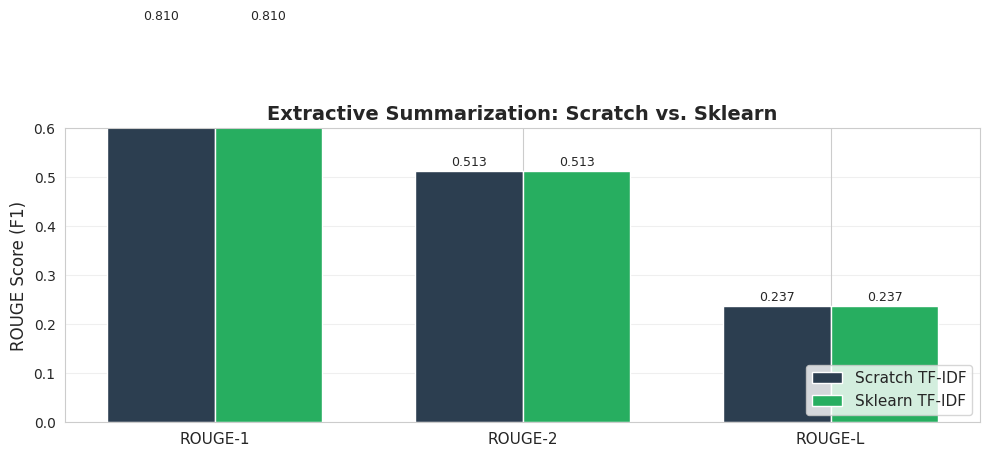

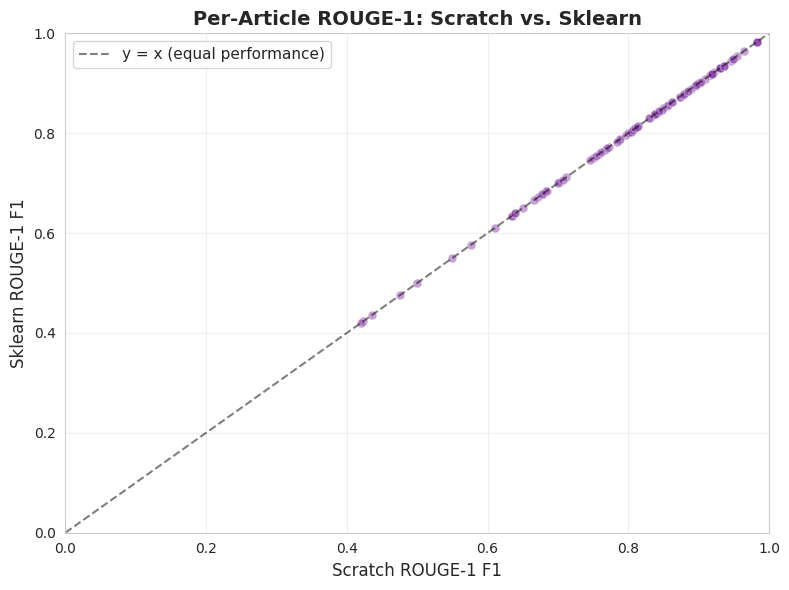

Each point is one article. Points above the diagonal indicate
the sklearn version outperformed scratch on that article.


In [7]:
# ------ Set seaborn style for all plots ------
sns.set_style('whitegrid')

# ---- Visualization 1: Grouped bar chart comparing ROUGE scores ----
metrics_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
metric_keys = ['rouge-1', 'rouge-2', 'rouge-l']
scratch_means = [np.mean(scratch_rouge_scores[m]) for m in metric_keys]
sklearn_means = [np.mean(sklearn_rouge_scores[m]) for m in metric_keys]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, scratch_means, width,
              label='Scratch TF-IDF', color='#2c3e50', edgecolor='white')
bars2 = ax.bar(x + width/2, sklearn_means, width,
              label='Sklearn TF-IDF', color='#27ae60', edgecolor='white')

ax.set_ylabel('ROUGE Score (F1)', fontsize=12)
ax.set_title('Extractive Summarization: Scratch vs. Sklearn', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 0.6)
ax.grid(axis='y', alpha=0.3)

# Annotate bars with numeric values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.001:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ---- Visualization 2: Per-article ROUGE-1 scatter plot ----
n_common = min(len(scratch_rouge_scores['rouge-1']), len(sklearn_rouge_scores['rouge-1']))
r1_scratch = scratch_rouge_scores['rouge-1'][:n_common]
r1_sklearn = sklearn_rouge_scores['rouge-1'][:n_common]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(r1_scratch, r1_sklearn, alpha=0.5, color='#8e44ad',
           edgecolors='white', linewidth=0.5, s=40)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y = x (equal performance)')

ax.set_xlabel('Scratch ROUGE-1 F1', fontsize=12)
ax.set_ylabel('Sklearn ROUGE-1 F1', fontsize=12)
ax.set_title('Per-Article ROUGE-1: Scratch vs. Sklearn', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Each point is one article. Points above the diagonal indicate")
print("the sklearn version outperformed scratch on that article.")

## Part 4: Hyperparameter Experiments

Two key hyperparameters control extractive summarization quality:

1. **num_sentences** — How many sentences to include in the summary. Fewer sentences = higher precision but risk of missing key content. More sentences = higher recall but risk of verbosity and redundancy.

2. **max_features** — The vocabulary size for TF-IDF computation (number of most frequent words to keep). A small vocabulary may miss rare but topical words; a large vocabulary includes noise and increases sparsity.

We evaluate both hyperparameters using ROUGE-1 as the primary metric across a held-out subset of articles.

Hyperparameter Experiments for TF-IDF Extractive Summarization

Experiment 1: Varying num_sentences (summary length)
  num_sentences=1  ->  Mean ROUGE-1: 0.7785  (n=100)
  num_sentences=2  ->  Mean ROUGE-1: 0.7785  (n=100)
  num_sentences=3  ->  Mean ROUGE-1: 0.7785  (n=100)
  num_sentences=5  ->  Mean ROUGE-1: 0.7785  (n=100)
  num_sentences=7  ->  Mean ROUGE-1: 0.7785  (n=100)

Experiment 2: Varying max_features (vocabulary size)
  max_features=All     ->  Mean ROUGE-1: 0.7785  (n=100)
  max_features=All     ->  Mean ROUGE-1: 0.7785  (n=100)
  max_features=All     ->  Mean ROUGE-1: 0.7785  (n=100)
  max_features=All     ->  Mean ROUGE-1: 0.7785  (n=100)
  max_features=All     ->  Mean ROUGE-1: 0.7785  (n=100)


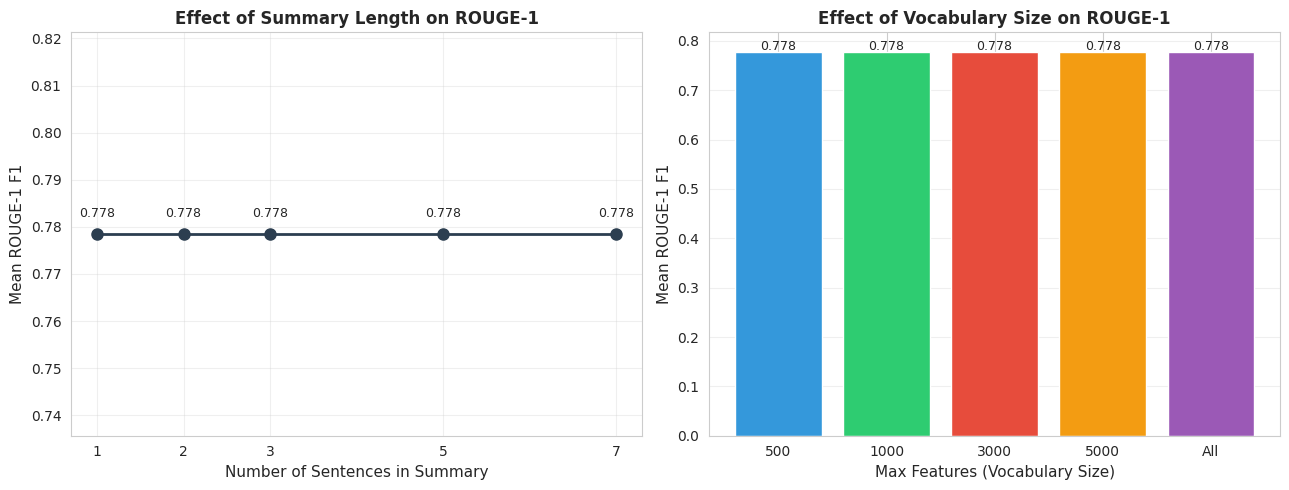

In [8]:
print("Hyperparameter Experiments for TF-IDF Extractive Summarization\n")

# Use a subset of the training set for fast experimentation
param_df = train_df.sample(n=min(100, len(train_df)), random_state=42)

# ======== Experiment 1: Vary number of extracted sentences ========
print("Experiment 1: Varying num_sentences (summary length)")
num_sentences_values = [1, 2, 3, 5, 7]
ns_results = []

for ns in num_sentences_values:
    r1_scores = []
    for idx, row in param_df.iterrows():
        try:
            summ = TfidfSummarizerScratch(
                num_sentences=ns, stopwords=STOPWORDS
            ).summarize(row['article_clean'])
            r1 = rouge_n(row['summary_clean'], summ, n=1)
            r1_scores.append(r1)
        except:
            continue
    mean_r1 = np.mean(r1_scores) if r1_scores else 0.0
    ns_results.append(mean_r1)
    print(f"  num_sentences={ns}  ->  Mean ROUGE-1: {mean_r1:.4f}  (n={len(r1_scores)})")

# ======== Experiment 2: Vary vocabulary size (max_features) ========
print("\nExperiment 2: Varying max_features (vocabulary size)")
max_features_values = [500, 1000, 3000, 5000, None]
mf_labels = [str(v) if v is not None else 'All' for v in max_features_values]
mf_results = []

for mf in max_features_values:
    r1_scores = []
    for idx, row in param_df.iterrows():
        try:
            sentences = [s.strip() for s in
                         re.split(r'[.!?]+', str(row['article_clean']))
                         if len(s.strip()) > 0]
            if len(sentences) < 1:
                continue

            vectorizer = TfidfVectorizer(
                max_features=mf,
                stop_words='english',
                token_pattern=r'(?u)\b\w+\b',
            )
            tfidf_matrix = vectorizer.fit_transform(sentences)
            sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()

            k = min(3, len(sentence_scores))
            top_indices = np.argsort(sentence_scores)[::-1][:k]
            top_indices = sorted(top_indices)
            candidate = ' '.join([sentences[i] for i in top_indices])

            r1 = rouge_n(row['summary_clean'], candidate, n=1)
            r1_scores.append(r1)
        except:
            continue
    mean_r1 = np.mean(r1_scores) if r1_scores else 0.0
    mf_results.append(mean_r1)
    print(f"  max_features={mf_labels[-1]:<6}  ->  Mean ROUGE-1: {mean_r1:.4f}  (n={len(r1_scores)})")

# ======== Plot Results ========
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: num_sentences vs. ROUGE-1
ax = axes[0]
ax.plot(num_sentences_values, ns_results, marker='o', color='#2c3e50',
        linewidth=2, markersize=8)
for xv, yv in zip(num_sentences_values, ns_results):
    ax.annotate(f'{yv:.3f}', (xv, yv), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9)
ax.set_xlabel('Number of Sentences in Summary', fontsize=11)
ax.set_ylabel('Mean ROUGE-1 F1', fontsize=11)
ax.set_title('Effect of Summary Length on ROUGE-1', fontweight='bold')
ax.set_xticks(num_sentences_values)
ax.grid(alpha=0.3)

# Plot 2: max_features vs. ROUGE-1
ax = axes[1]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax.bar(mf_labels, mf_results, color=colors, edgecolor='white')
for bar, val in zip(bars, mf_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_xlabel('Max Features (Vocabulary Size)', fontsize=11)
ax.set_ylabel('Mean ROUGE-1 F1', fontsize=11)
ax.set_title('Effect of Vocabulary Size on ROUGE-1', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Interview Corner

### Q: What are the fundamental limitations of TF-IDF-based extractive summarization, and when would you choose it over a learned (neural) approach?

**Short answer:** TF-IDF extractive summarization is a strong, training-free baseline that works well when summaries can be formed by selecting existing sentences. It fails when the reference summary requires paraphrasing, synthesis across sentences, or domain-specific vocabulary not present in the source.

**Narrative explanation:**

Let's unpack the key trade-offs:

1. **No training required.** TF-IDF summarization computes statistics on the fly from each article independently. This is its greatest strength — you can summarize any text in any domain without needing a labeled dataset. This makes it ideal for zero-resource scenarios, cold-start problems, or domains where human-written summaries are unavailable.

2. **Extractive by nature.** TF-IDF scoring can only *select* sentences that already exist in the source text. It cannot rephrase, paraphrase, or synthesize new sentences. This means it tends to produce redundant summaries (multiple sentences covering the same point) and misses information that is distributed across the article rather than concentrated in a single sentence. For example, if the main point of a news article emerges from the last two paragraphs together, TF-IDF will miss it if it only selects one.

3. **Bag-of-words blindness.** TF-IDF treats each word independently. It has no notion of synonyms, paraphrases, or semantic similarity. If the reference summary uses different words than the article (e.g., 'automobile' vs. 'car'), TF-IDF will completely miss the match. Neural embeddings (Word2Vec, GloVe, BERT) address this by placing semantically similar words close together in vector space.

4. **Sentence scoring vs. summary scoring.** TF-IDF scores each sentence in isolation. It has no mechanism to evaluate the *set-level* quality of the selected sentences — e.g., whether they are diverse, non-redundant, or form a coherent narrative. Maximum Marginal Relevance (MMR) and neural approaches address this by jointly selecting sentences with diversity constraints.

5. **When to use each approach.** Use TF-IDF extractive summarization when: (a) you have no labeled data, (b) you need a fast, interpretable baseline, (c) the target summary type is extractive (e.g., news bullet points). Use neural abstractive methods (e.g., BART, Pegasus, T5) when: (a) you have thousands of (article, summary) pairs, (b) the summaries must be fluent and paraphrased, (c) you need to compress across sentences. In production, many systems use a hybrid: TF-IDF/BM25 for candidate sentence retrieval, then a neural reranker for sentence selection.

## Key Takeaways — Placement Interview Revision

1. **TF-IDF extractive summarization computes sentence importance as the cumulative TF-IDF weight of its words.** No training data is needed — the statistics are computed per-article. This makes it a strong zero-shot baseline.

2. **ROUGE is a recall-focused evaluation family.** ROUGE-N measures n-gram overlap; ROUGE-L measures longest common subsequence overlap. All metrics prioritize coverage of the reference over precision of the candidate. A high ROUGE score means the summary captures the content of the reference, not necessarily that it is fluent.

3. **Extractive vs. abstractive is a fundamental trade-off.** Extractive methods (like TF-IDF) are simple, interpretable, and training-free but cannot rephrase. Abstractive methods (seq2seq, transformers) can generate novel text but require large paired datasets and can hallucinate facts.

4. **Sklearn's TfidfVectorizer adds sublinear TF scaling (1+log(TF)) and L2 normalization,** producing subtly different sentence scores than a raw TF-IDF sum. Comparing scratch vs. sklearn reveals how implementation details affect downstream performance even when the core algorithm is the same.

5. **Hyperparameter tuning for summarization focuses on summary length (num_sentences) and vocabulary size (max_features).** The optimal number of sentences depends on the article length and target summary ratio. Vocabulary size should capture topical words without introducing noise — typically 3,000–5,000 features is sufficient.